<a href="https://colab.research.google.com/github/Yashidwivedi438/yashis-demo/blob/main/bar%20charts%20and%20pie%20charts%20R_Programming.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Basic Random Forest Classification

In [ ]:
# Install required package (run once)
install.packages("randomForest")

# Load library
library(randomForest)

# Load built-in dataset iris
data(iris)

# Build Random Forest model
# Species is the target variable, . means use all other columns as features
rf_model <- randomForest(Species ~ ., data = iris, ntree = 100)

# Print model summary
#print(rf_model)

# Predict using the trained model
pred <- predict(rf_model, iris)

# Check accuracy
accuracy <- mean(pred == iris$Species)
cat("Model Accuracy:", accuracy, "\n")


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.



Model Accuracy: 1 


The Random Forest used 100 trees.

Each split considered 2 random features.

Training accuracy = 100%, but OOB error = 5.33% (realistic).

setosa is easiest to classify, while versicolor & virginica are sometimes confused.
Species ~ . → Predict Species using all other columns (Sepal.Length, Sepal.Width, Petal.Length, Petal.Width).

data = iris → Dataset used.

ntree = 100 → 100 decision trees were built.
Since the target (Species) is categorical, the model is a classification random forest (not regression).
The forest has 100 decision trees combined (majority voting decides final class).
At each tree node, the model randomly picks 2 features (out of 4 features in iris dataset) to decide the best split.

This randomness helps reduce overfitting and makes the forest more robust.
OOB (Out-of-Bag) estimate of error rate
OOB error = built-in cross-validation in Random Forest.

Each tree is trained on a random subset of data (bootstrapping). Data not included in that subset is called OOB samples.

The model tests itself on these unseen samples to estimate error.

Here, error = 5.33%, meaning accuracy ≈ 94.67%.
           setosa versicolor virginica class.error
setosa         50          0         0        0.00
versicolor      0         47         3        0.06
virginica       0          5        45        0.10
Rows = actual species, columns = predicted species.
setosa: All 50 were predicted correctly (perfect).

versicolor: 47 correct, 3 wrongly predicted as virginica.

virginica: 45 correct, 5 wrongly predicted as versicolor.

class.error is misclassification rate for each class.
Since predictions were made on the same training data, the model gives 100% accuracy here.

That’s why OOB error (≈5.33%) is more realistic for generalization.
OOB accuracy = unbiased estimate
In Random Forest, each tree is trained on a bootstrap sample (~63% of data).

The remaining ~37% (Out-of-Bag samples) are not seen by that tree and are used for testing.

This acts like built-in cross-validation.


Random Forest with Train-Test Split

In [ ]:
install.packages("randomForest", dependencies = TRUE)

# Load library
library(randomForest)

# Use iris dataset
data(iris)

# Split data into train (70%) and test (30%)
set.seed(42)
sample_index <- sample(1:nrow(iris), 0.7 * nrow(iris))
train_data <- iris[sample_index, ]
test_data <- iris[-sample_index, ]

# Build Random Forest model on training data
rf_model2 <- randomForest(Species ~ ., data = train_data, ntree = 50)

# Predict on test data
predictions2 <- predict(rf_model2, test_data)

# Compare predictions with actual values
conf_matrix <- table(predictions2, test_data$Species)
print(conf_matrix)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



            
predictions2 setosa versicolor virginica
  setosa         12          0         0
  versicolor      0         14         1
  virginica       0          1        17


Step 1: Understand rows and columns

Rows → predicted species by the model (predictions2).

Columns → actual species in the test data (test_data$Species).

Diagonal values (top-left to bottom-right) are correct predictions.

Off-diagonal values are misclassifications.

Step 2: Analyze each class

Setosa:

Predicted as setosa: 12

Misclassified as versicolor: 0

Misclassified as virginica: 0
✅ All setosa correctly predicted

Versicolor:

Predicted as versicolor: 14

Misclassified as virginica: 1

Misclassified as setosa: 0
✅ Mostly correct, 1 mistake

Virginica:

Predicted as virginica: 17

Misclassified as versicolor: 1

Misclassified as setosa: 0
✅ Mostly correct, 1 mistake


Step 3: Overall performance

Total test samples = 12 + 14 + 17 + 1 + 1 = 45

Correct predictions = 12 + 14 + 17 = 43

Accuracy = 43 / 45 ≈ 95.6%

A confusion matrix in R (and in general machine learning) is a table that summarizes how well a classification model performs by comparing the predicted labels against the actual labels.
Rows → Model’s predicted values.

Columns → Actual/true values from the dataset.

Diagonal values → Correct predictions.

Off-diagonal values → Misclassifications.

	Actual setosa	Actual versicolor	Actual virginica
Pred setosa	12	0	0
Pred versicolor	0	14	1
Pred virginica	0	1	17

Interpretation:

12 setosa predicted correctly. ✅

14 versicolor predicted correctly, but 1 versicolor misclassified as virginica. ⚠️

17 virginica predicted correctly, but 1 misclassified as versicolor. ⚠️

Confusion Matrix in R

In [ ]:
# Install and load caret package
install.packages("caret")
library(caret)

# Load the iris dataset
data(iris)

# Split dataset into train (70%) and test (30%)
set.seed(123)
sample_index <- sample(1:nrow(iris), 0.7 * nrow(iris))
train_data <- iris[sample_index, ]
test_data <- iris[-sample_index, ]

# Build a simple Random Forest model
install.packages("randomForest")
library(randomForest)
rf_model <- randomForest(Species ~ ., data = train_data, ntree = 50)

# Predict on test data
predictions <- predict(rf_model, test_data)
actual <- test_data$Species

# Create confusion matrix using caret
conf_matrix <- confusionMatrix(predictions, actual)
print(conf_matrix)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Confusion Matrix and Statistics

            Reference
Prediction   setosa versicolor virginica
  setosa         14          0         0
  versicolor      0         17         0
  virginica       0          1        13

Overall Statistics
                                          
               Accuracy : 0.9778          
                 95% CI : (0.8823, 0.9994)
    No Information Rate : 0.4             
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.9664          
                                          
 Mcnemar's Test P-Value : NA              

Statistics by Class:

                     Class: setosa Class: versicolor Class: virginica
Sensitivity                 1.0000            0.9444           1.0000
Specificity                 1.0000            1.0000           0.9688
Pos Pred Value              1.0000            1.0000           0.9286
Neg Pred Value              1.0000            0.9643           1.0000
P

Rows → predicted labels, Columns → actual labels

Diagonal values (14, 17, 13) → correct predictions

Off-diagonal values (1 at virginica row, versicolor column) → misclassification

Example: 1 virginica sample was predicted as versicolor

Overall Statistics

Accuracy : 0.9778 → ~97.78% of predictions are correct

95% CI : (0.8823, 0.9994) → Confidence interval for accuracy

No Information Rate : 0.4 → Accuracy if we always predicted the most common class

P-Value [Acc > NIR] : < 2.2e-16 → Accuracy is significantly better than random guess

Kappa : 0.9664 → Agreement between predictions and actual labels, adjusted for chance (1 = perfect)

Sensitivity (Recall) → True positive rate for each class

Specificity → True negative rate

Pos Pred Value (Precision) → Fraction of predicted positives that are correct

Balanced Accuracy → Average of Sensitivity and Specificity

Plotting Confusion Matrix

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



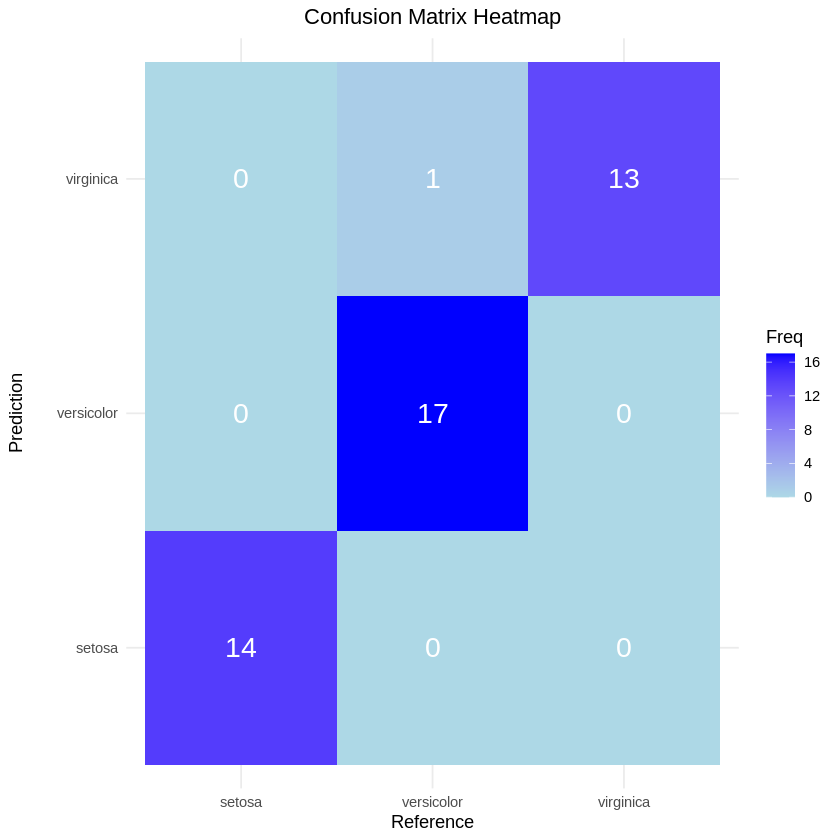

In [ ]:
# Install packages if not already installed
install.packages("ggplot2")
install.packages("reshape2")

library(ggplot2)
library(reshape2)

# Use the confusion matrix from caret
cm <- confusionMatrix(predictions, actual)$table

# Convert to data frame for plotting
cm_df <- as.data.frame(cm)
colnames(cm_df) <- c("Prediction", "Reference", "Freq")

# Plot using ggplot2
ggplot(data = cm_df, aes(x = Reference, y = Prediction, fill = Freq)) +
  geom_tile() +
  geom_text(aes(label = Freq), color = "white", size = 6) +
  scale_fill_gradient(low = "lightblue", high = "blue") +
  theme_minimal() +
  ggtitle("Confusion Matrix Heatmap") +
  theme(plot.title = element_text(hjust = 0.5))


Simple Decision Tree using built-in dataset

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



1 
setosa 
Levels: setosa versicolor virginica

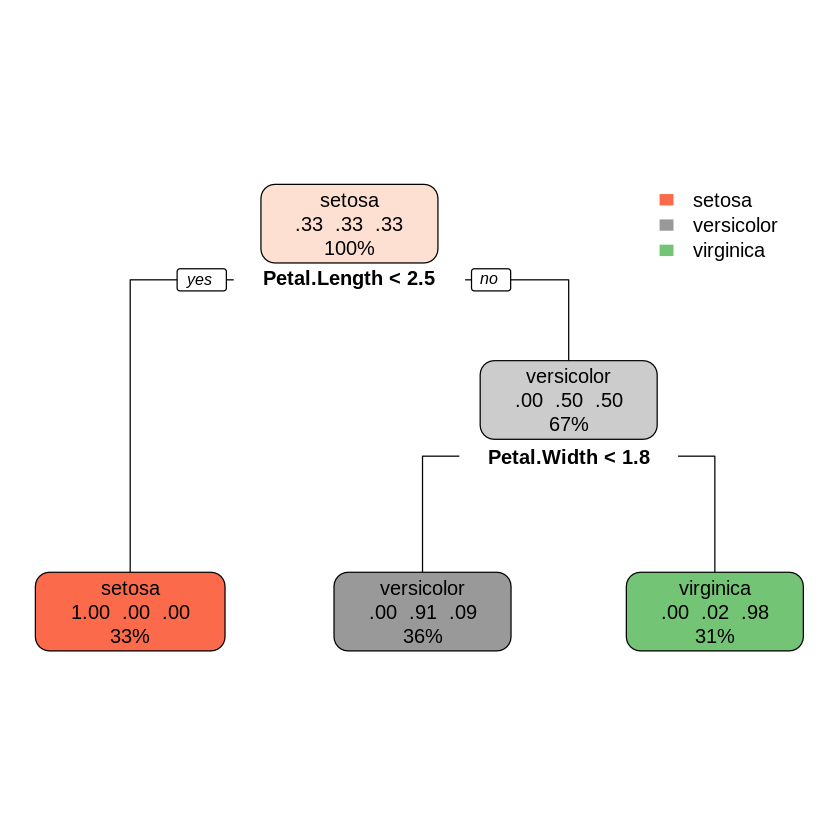

In [ ]:
# Install required package
install.packages("rpart")
install.packages("rpart.plot")

# Load libraries
library(rpart)
library(rpart.plot)

# Use built-in dataset
data(iris)

# Create a simple decision tree model
model <- rpart(Species ~ ., data = iris, method = "class")

# Plot the tree
rpart.plot(model)

# Predict for a new data point
new_data <- data.frame(Sepal.Length = 5.1, Sepal.Width = 3.5,
                       Petal.Length = 1.4, Petal.Width = 0.2)
predict(model, new_data, type = "class")


Decision Tree Explanation (Iris Dataset)

This tree helps classify a flower into one of three species — Setosa, Versicolor, or Virginica — based on its Petal Length and Petal Width.

Step 1: Root Node

The first split happens at Petal.Length < 2.5

If Yes, the flower is predicted as Setosa (orange box).

If No, the model checks another condition.

Step 2: Right Branch (for Petal.Length ≥ 2.5)

The next condition checks Petal.Width < 1.8

If Yes, the flower is likely Versicolor (gray box).

If No, the flower is likely Virginica (green box).

Interpretation of Numbers in Each Box

Each box shows:

The predicted species name (e.g., setosa, versicolor, virginica)

The probability distribution for all three species
(e.g., .00 .91 .09 means 91% chance of versicolor)

The percentage of total samples in that group.

Flowers with small petals (Petal.Length < 2.5) are Setosa.

Flowers with medium-sized petals and narrow width (<1.8) are Versicolor.

Flowers with larger and wider petals are Virginica.

rpart – used for creating decision tree models (Recursive Partitioning and Regression Trees).

rpart.plot – used for plotting (visualizing) the decision tree in a simple and understandable way.

The iris dataset is a built-in dataset in R that contains measurements of 150 flowers from three species:
Setosa

Versicolor

Virginica

Each flower has 4 numeric attributes:

Sepal.Length

Sepal.Width

Petal.Length

Petal.Width

and one categorical variable: Species.

model <- rpart(Species ~ ., data = iris, method = "class")
rpart() creates a decision tree model.

The formula Species ~ . means “predict the Species using all other variables (.) in the dataset.”

data = iris tells R to use the iris dataset.

method = "class" specifies that this is a classification problem (since Species is categorical)

The resulting object model stores the trained decision tree.
rpart.plot(model)
This function visualizes the decision tree structure.
It shows how the dataset is split at each node based on feature values to classify the flowers into the three species.

new_data <- data.frame(Sepal.Length = 5.1, Sepal.Width = 3.5,
                       Petal.Length = 1.4, Petal.Width = 0.2)
predict(model, new_data, type = "class")
A new data point (flower) is created using the same four measurements.

predict() uses the trained model to predict the flower’s species.

type = "class" ensures the output is the predicted species name, not probabilities.
setosa
because those measurements match the typical pattern for the setosa species.
This program trains a decision tree on the iris dataset, visualizes the tree, and uses it to predict the species of a new flower based on its sepal and petal dimensions.

Decision Tree on Custom Small Dataset

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



n= 6 

node), split, n, loss, yval, (yprob)
      * denotes terminal node

1) root 6 3 Fail (0.5000000 0.5000000) *
[1] "Predicted Result: Fail"


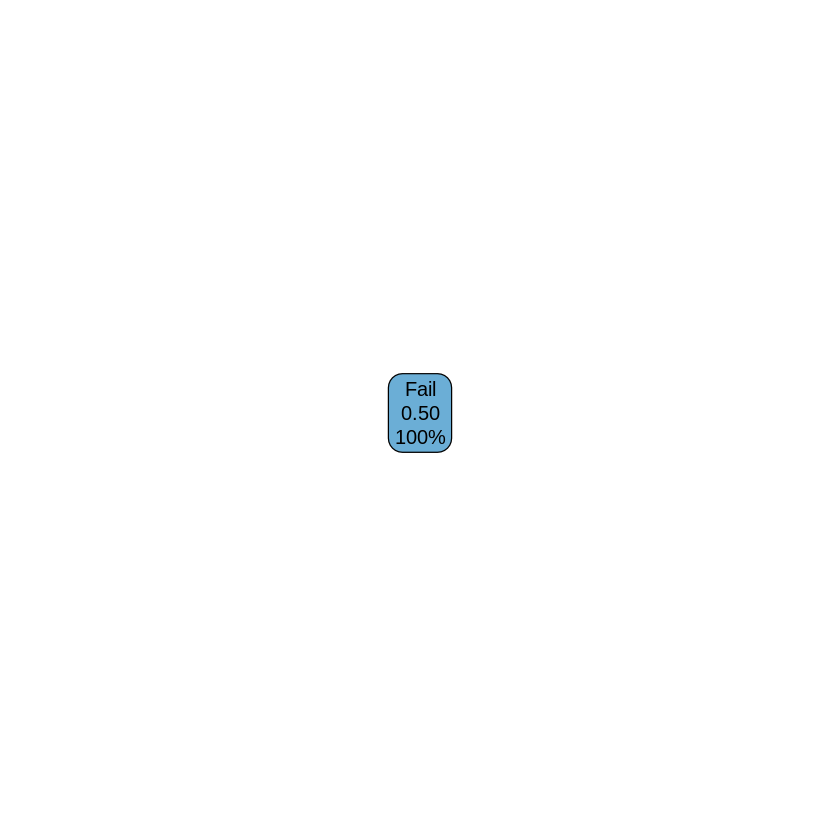

In [ ]:
# Install and load required packages
install.packages("rpart")
install.packages("rpart.plot")

library(rpart)
library(rpart.plot)

# Create simple student dataset
student_data <- data.frame(
  Attendance = c("High", "Low", "High", "Medium", "Low", "High"),
  Homework = c("Yes", "No", "Yes", "Yes", "No", "No"),
  Result = c("Pass", "Fail", "Pass", "Pass", "Fail", "Fail")
)

# Build decision tree model
model <- rpart(Result ~ Attendance + Homework, data = student_data, method = "class")

# Plot the decision tree
rpart.plot(model)

# Print the tree structure in console
print(model)

# Test the model with new input
test <- data.frame(Attendance = "High", Homework = "Yes")

# Predict result for new student
prediction <- predict(model, test, type = "class")
print(paste("Predicted Result:", prediction))


Fail	The predicted class at this node is “Fail”.
0.50	The probability (or proportion) — here 50% of the data are “Fail” and 50% “Pass.”
100%	This node covers 100% of all records — the whole dataset.

root 6	There are 6 total observations (rows) in your dataset.
loss 3	3 samples were misclassified if the model predicted everything as one class (Fail).
yval Fail	The predicted class at the root node is Fail.
(0.5 0.5)	The probability for both classes — 50% Pass, 50% Fail.

The tree didn’t split at all — notice only one node (root) in the output.
That means the model didn’t find any split (Attendance or Homework) that improved classification enough according to its default settings.

Small dataset problem:
With only 6 records, and an even 3 Pass vs 3 Fail, R’s rpart() decided that splitting doesn’t statistically help — so it made no branches.

Result:
The model says:
“There’s no clear rule; I’ll just predict the most frequent or first label — here it’s Fail.”

The decision tree didn’t find any useful split on Attendance or Homework.

With such a small dataset (6 rows, evenly split between Pass and Fail), the algorithm couldn’t find a statistically “better” rule.

So it decided not to branch at all and just predict the majority or first class (“Fail”) for everything.

Decision Tree for Car Evaluation

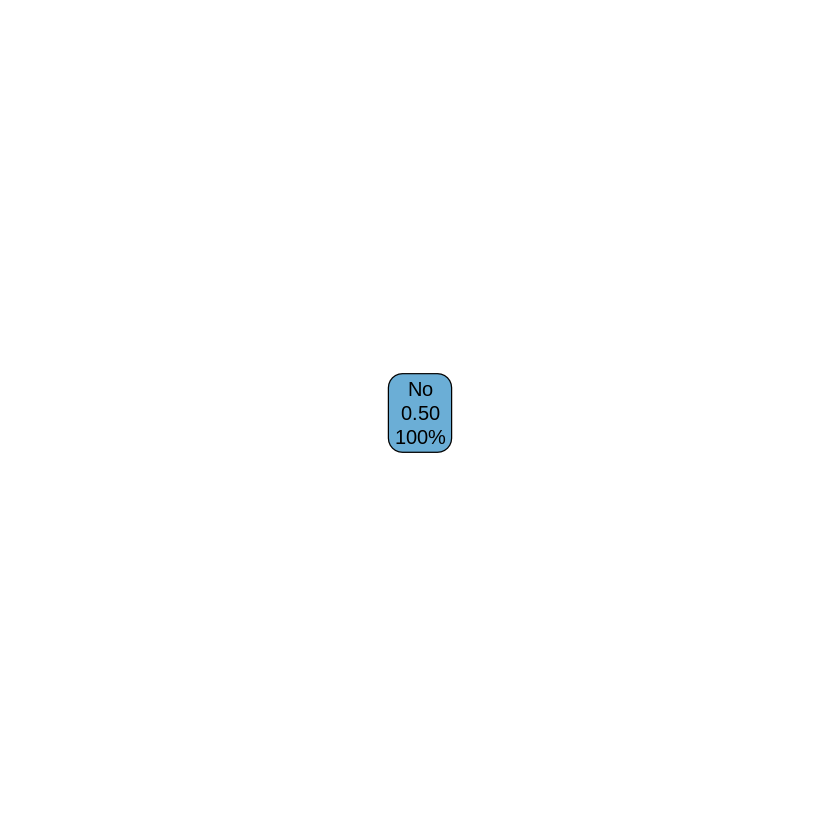

In [ ]:
# Create dataset
car_data <- data.frame(
  Speed = c("Fast", "Slow", "Fast", "Slow", "Fast", "Slow"),
  Safety = c("High", "Low", "High", "Medium", "Medium", "Low"),
  Buy = c("Yes", "No", "Yes", "No", "Yes", "No")
)

# Build and plot tree
model <- rpart(Buy ~ Speed + Safety, data = car_data, method = "class")
rpart.plot(model)


The dataset has 3 “Yes” and 3 “No” → perfectly balanced (50% each).
That’s already confusing for the model — no strong majority.

The variables Speed and Safety don’t create a clear pattern for R’s default settings to split, so it stops early and predicts the first or most frequent class (here “No”).

Normal Distribution

The Normal Distribution (also called Gaussian Distribution) is a continuous probability distribution that forms a bell-shaped curve.

It is symmetric around its mean (μ), meaning most of the data points lie close to the mean.


Parameters:

μ (mean): Center of the curve.

σ (standard deviation): Controls the spread or width of the curve.

Used in statistics, machine learning, and natural data analysis where data tends to cluster around a mean value.

Examples: Heights, weights, exam scores, errors in measurement, etc.

Many natural phenomena follow it.

Easy to apply for statistical inference (like confidence intervals, hypothesis testing).

Central Limit Theorem supports its importance — sums of random variables tend to be normal.

Lets perform one example to Genrate Normal Distribution using dnorm() in R.

In [ ]:
# creating a sequence of values
# between -15 to 15 with a difference of 0.1
x = seq(-15, 15, by=0.1)

y = dnorm(x, mean(x), sd(x))

# output to be present as PNG file
png(file="dnormExample.png")

# Plot the graph.
plot(x, y)

# saving the file
dev.off()

agg_record_1385484853 
                    2

agg_record_1198180418 is the internal device name for the PNG device (it may vary by system/version).

2 is the device number that was closed.

# Create a sequence from -15 to 15
x = seq(-15, 15, by=0.1)

# Compute y using the normal distribution density
y = dnorm(x, mean(x), sd(x))

# Save plot as PNG
png(file = "dnormExample.png")

# Plot the graph
plot(x, y)

# Close device
dev.off()


1. seq(-15, 15, by=0.1)

This creates 301 values between −15 and +15, spaced by 0.1.
So, x = -15, -14.9, -14.8, …, 14.9, 15.

2. dnorm(x, mean(x), sd(x))

This calculates the normal (Gaussian) probability density for each x-value, using:

mean(x) → mean of −15 to 15, which is 0

sd(x) → standard deviation of −15 to 15, which is roughly 8.7

So, you’re plotting a normal distribution centered at 0 with SD ≈ 8.7 — a very wide and flat bell curve.

That’s why your graph looks broad and low, not tall and narrow.
The plotted graph

X-axis (x): Values from −15 to +15

Y-axis (y): Probability density computed using the normal distribution

Because of the wide SD, the curve rises smoothly from both ends toward the center (0), peaks at ~0.045, then decreases again symmetrically.

Lets perform one example to Genrate Normal Distribution using pnorm() in R.

In [ ]:
# creating a sequence of values
# between -10 to 10 with a difference of 0.1
x <- seq(-10, 10, by=0.1)

y <- pnorm(x, mean = 2.5, sd = 2)

# output to be present as PNG file
png(file="pnormExample.png")

# Plot the graph.
plot(x, y)

# saving the file
dev.off()

agg_record_1633384664 
                    2

In R, this kind of S-shaped (sigmoid) curve is created using:

x <- seq(-10, 10, by = 0.1)     # sequence of x values
y <- pnorm(x, mean = 0, sd = 1) # cumulative probabilities for standard normal distribution

plot(x, y, type = "o")          # plotting

pnorm() gives the cumulative probability (area under the normal curve to the left of a value x).

It tells us: “What is the probability that a normally distributed random variable is less than or equal to x?”

The x-axis → possible values (from -10 to +10).

The y-axis → cumulative probability (from 0 to 1).

Region	Interpretation
Left side (x < -3)	Probability is close to 0 — almost no data below this value.
Middle (around x = 0)	Probability ≈ 0.5 — half of the data lies below 0 (mean).
Right side (x > 3)	Probability is close to 1 — almost all data below this value.

The S-shape comes because:

For very small x, the cumulative probability is near 0.

Around the mean, the probability increases rapidly.

For very large x, it flattens near 1 (since total probability = 1).

Function	Meaning	Shape
dnorm()	Density function (height of bell curve)	Bell-shaped curve
pnorm()	Cumulative probability (area up to x)	S-shaped curve

Genrate Normal Distribution using qnorm()

In [ ]:
# Create a sequence of probability values
# incrementing by 0.02.
x <- seq(0, 1, by = 0.02)

y <- qnorm(x, mean(x), sd(x))

# output to be present as PNG file
png(file = "qnormExample.png")

# Plot the graph.
plot(x, y)

# Save the file.
dev.off()

agg_record_787267152 
                   2

In [ ]:
# Create a vector of 1000 random numbers
# with mean=90 and sd=5
x <- rnorm(10000, mean=90, sd=5)

# output to be present as PNG file
png(file = "rnormExample.png")

# Create the histogram with 50 bars
hist(x, breaks=50)

# Save the file.
dev.off()

agg_record_60754576 
                  2

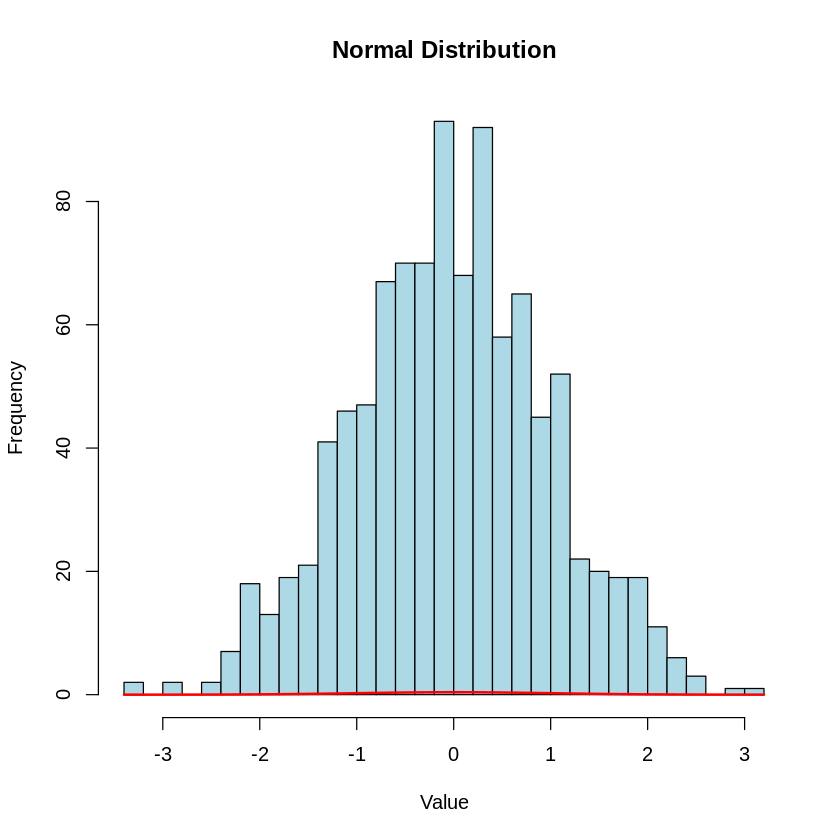

In [ ]:
# Normal Distribution Example
# Mean = 0, SD = 1 (Standard Normal Distribution)

# Generate random numbers following normal distribution
data <- rnorm(1000, mean = 0, sd = 1)

# Plot histogram
hist(data, breaks = 30, col = "lightblue", main = "Normal Distribution", xlab = "Value")

# Add a normal density curve
curve(dnorm(x, mean = 0, sd = 1), add = TRUE, col = "red", lwd = 2)


rnorm(1000, mean, sd) → generates 1000 random normal values.

hist() → plots histogram.

curve(dnorm()) → overlays theoretical normal curve.

Binomial Distribution

The Binomial Distribution is a discrete probability distribution.

It represents the number of successes in a fixed number of independent trials with the same probability of success (p).
Parameters:

n: Number of trials

p: Probability of success in each trial

k: Number of successes
Used when outcomes are binary — success/failure, yes/no, 1/0.

Examples: Coin toss, number of defective items, number of students passing.

Advantages:

Simple model for binary outcomes.

Helps in probability estimation and statistical prediction.

| Feature    | Normal Distribution | Binomial Distribution           |
| ---------- | ------------------- | ------------------------------- |
| Type       | Continuous          | Discrete                        |
| Shape      | Bell-shaped curve   | Depends on n and p              |
| Parameters | Mean (μ), SD (σ)    | n (trials), p (success prob.)   |
| Examples   | Heights, IQ scores  | Coin tosses, pass/fail outcomes |


   Successes  Probability
1          0 0.0009765625
2          1 0.0097656250
3          2 0.0439453125
4          3 0.1171875000
5          4 0.2050781250
6          5 0.2460937500
7          6 0.2050781250
8          7 0.1171875000
9          8 0.0439453125
10         9 0.0097656250
11        10 0.0009765625


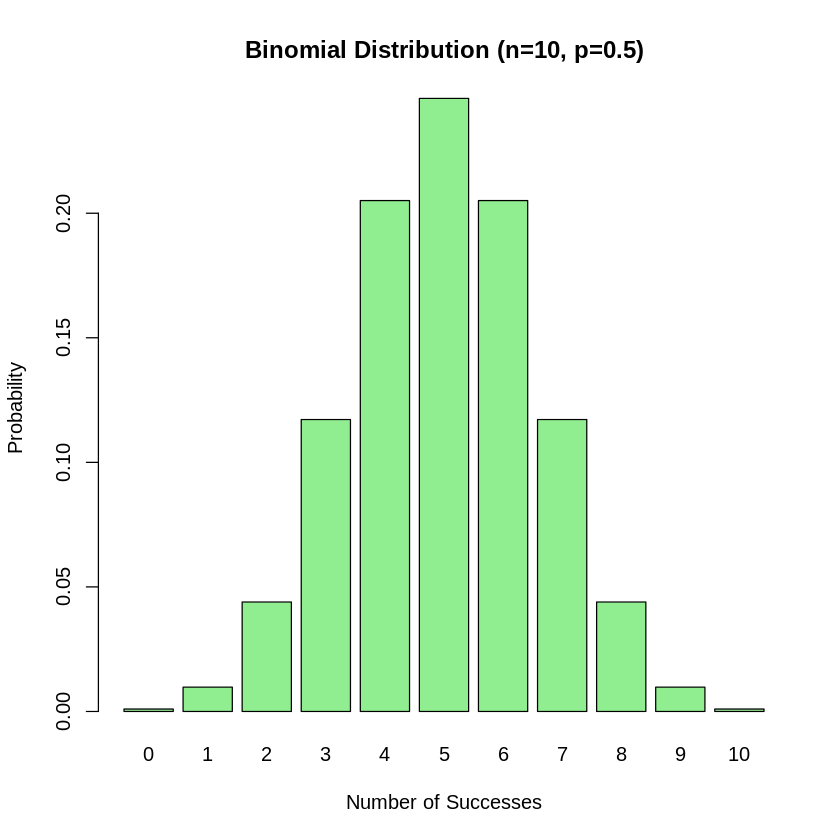

In [ ]:
# Binomial Distribution Example
# Number of trials = 10, Probability of success = 0.5

# Generate probabilities for 0 to 10 successes
x <- 0:10
prob <- dbinom(x, size = 10, prob = 0.5)

# Display probabilities
print(data.frame(Successes = x, Probability = prob))

# Plot distribution
barplot(prob, names.arg = x, col = "lightgreen", main = "Binomial Distribution (n=10, p=0.5)",
        xlab = "Number of Successes", ylab = "Probability")


dbinom(x, size, prob) → gives probability for each number of successes.

barplot() → shows the distribution visually.

| Concept  | Distribution Type | Example Function in R  | Common Use                        |
| -------- | ----------------- | ---------------------- | --------------------------------- |
| Normal   | Continuous        | `rnorm()`, `dnorm()`   | Natural data (height, weight)     |
| Binomial | Discrete          | `rbinom()`, `dbinom()` | Binary outcomes (success/failure) |


The normal distribution is a crucial concept in statistics, with applications ranging from data analysis to inferential statistics. R provides a variety of functions (dnorm(), pnorm(), qnorm(), rnorm()) to work with normal distributions, making it easy to perform statistical analyses and generate visualizations. Understanding how to use these tools is essential for effective data analysis in R.

Creating and Plotting a Simple Time Series

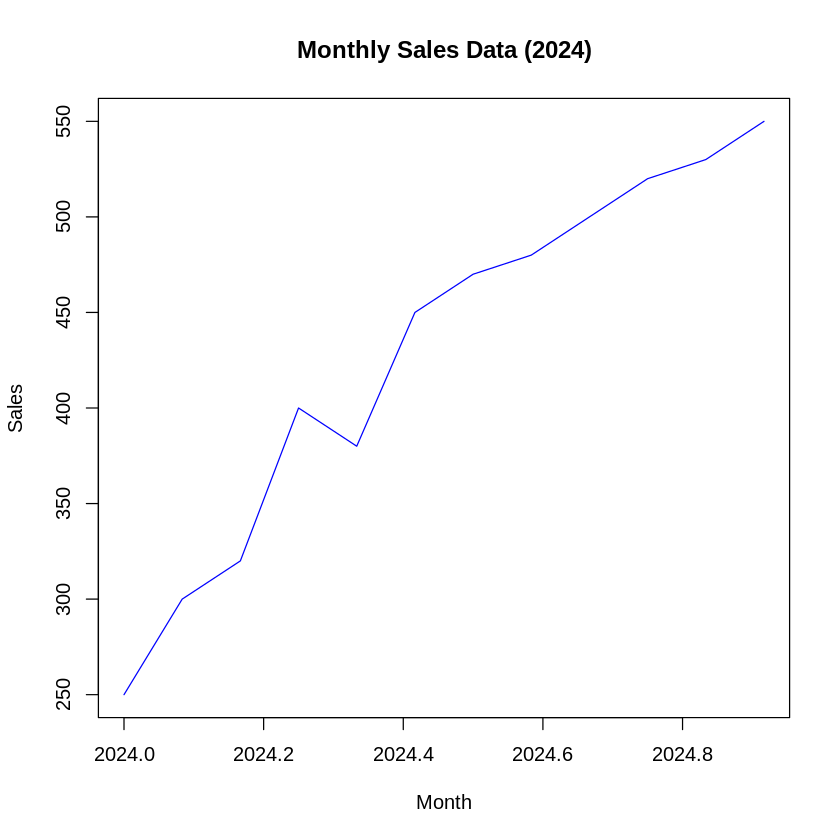

In [ ]:
# Creating monthly sales data
sales <- c(250, 300, 320, 400, 380, 450, 470, 480, 500, 520, 530, 550)
sales_ts <- ts(sales, start = c(2024, 1), frequency = 12)

# Plotting the time series
plot(sales_ts, main = "Monthly Sales Data (2024)", col = "blue", ylab = "Sales", xlab = "Month")


sales <- c(250, 300, 320, 400, 380, 450, 470, 480, 500, 520, 530, 550)

Here, a numeric vector named sales is created.

The function c() combines individual numbers into one vector.

Each number represents monthly sales — from January to December (12 months).

So, this is your raw sales data.
Example meaning:
January sales = 250, February = 300, March = 320 … December = 550.

sales_ts <- ts(sales, start = c(2024, 1), frequency = 12)

ts() creates a time series object from the vector sales.

start = c(2024, 1) means the series begins in January 2024.

frequency = 12 indicates that there are 12 observations per year (monthly data).

So now, sales_ts becomes a time series object, not just a numeric vector.
This lets R understand that data points are time-ordered.
Think of it as:
Telling R — “These numbers are monthly sales data for the year 2024.”

plot(sales_ts, main = "Monthly Sales Data (2024)", col = "blue", ylab = "Sales", xlab = "Month")

plot() draws the time series graph.

sales_ts is plotted on the y-axis (sales values).

Time (months) is automatically on the x-axis because it’s a time series.

main gives the title of the graph.

col = "blue" sets the line color.

ylab and xlab are the labels for Y and X axes.

📊 Result:
You get a blue line graph showing how sales increased month by month in 2024.
You can visually observe the trend (upward movement = growth).
sales <- c(...)	Creates a vector of monthly sales data.
ts()	Converts it into a time series object.
plot()	Displays the time-based trend visually.

Analyzing Temperature Data

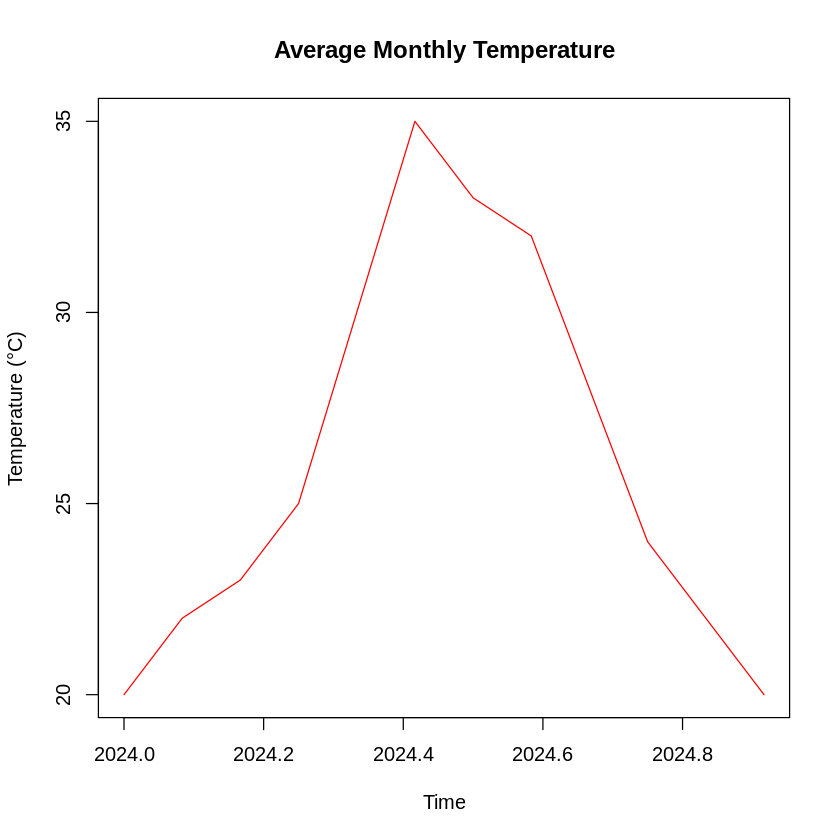

In [ ]:
# Example temperature data (daily average temperature)
temperature <- ts(c(20, 22, 23, 25, 30, 35, 33, 32, 28, 24, 22, 20),
                  start = c(2024, 1), frequency = 12)

plot(temperature, col="red", main="Average Monthly Temperature", ylab="Temperature (°C)")


ou can see seasonality — higher temperatures in middle months (summer), lower in start and end (winter).

Forecasting Using ARIMA Model

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘xts’, ‘TTR’, ‘quadprog’, ‘quantmod’, ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘tseries’, ‘urca’, ‘zoo’, ‘RcppArmadillo’


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



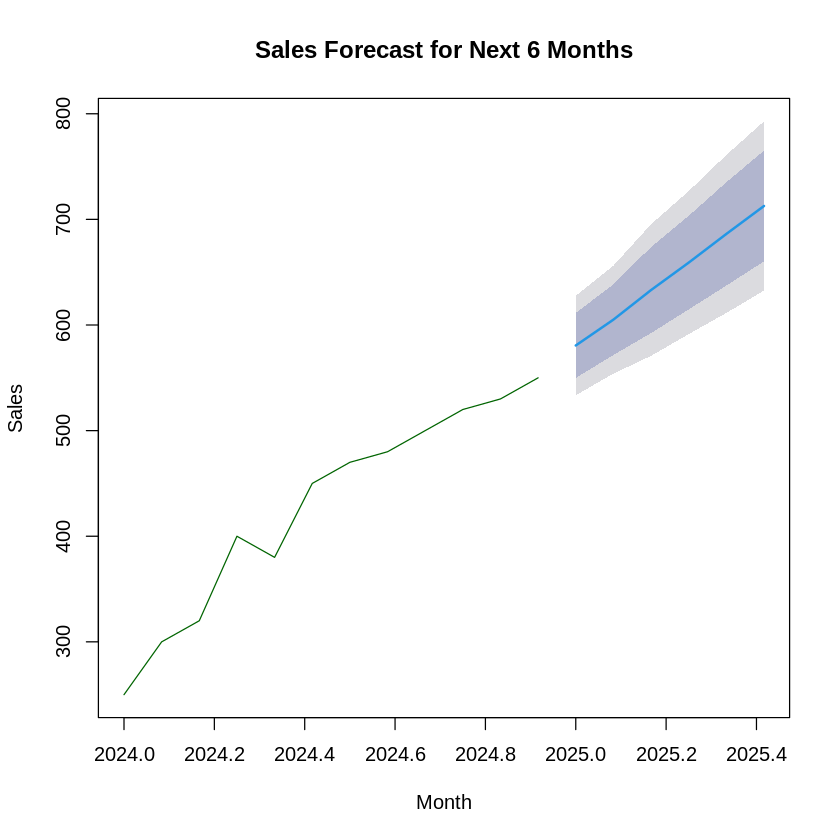

In [ ]:
#--------------------------------------------
# Example 3: Forecasting Using ARIMA Model
#--------------------------------------------

# Step 1: Install and load the required package
install.packages("forecast")   # Run only once to install
library(forecast)              # Load the package

# Step 2: Create monthly sales data
sales <- c(250, 300, 320, 400, 380, 450, 470, 480, 500, 520, 530, 550)
sales_ts <- ts(sales, start = c(2024, 1), frequency = 12)

# Step 3: Build ARIMA model automatically
sales_model <- auto.arima(sales_ts)

# Step 4: Forecast next 6 months
future_sales <- forecast(sales_model, h = 6)

# Step 5: Plot the forecast
plot(future_sales,
     main = "Sales Forecast for Next 6 Months",
     col = "darkgreen",
     xlab = "Month",
     ylab = "Sales")
